In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [8]:
from src.preprocessing import FraudDetectionPipeline
from src.model_train import ModelTrain
import joblib

2026-06-13 13:20:00,217 - INFO - Processed data loaded: (283726, 31)
2026-06-13 13:20:00,857 - INFO - No categorical features → Using regular SMOTE


Training shape before SMOTE: (226980, 30)
Training shape after  SMOTE: (339903, 30)


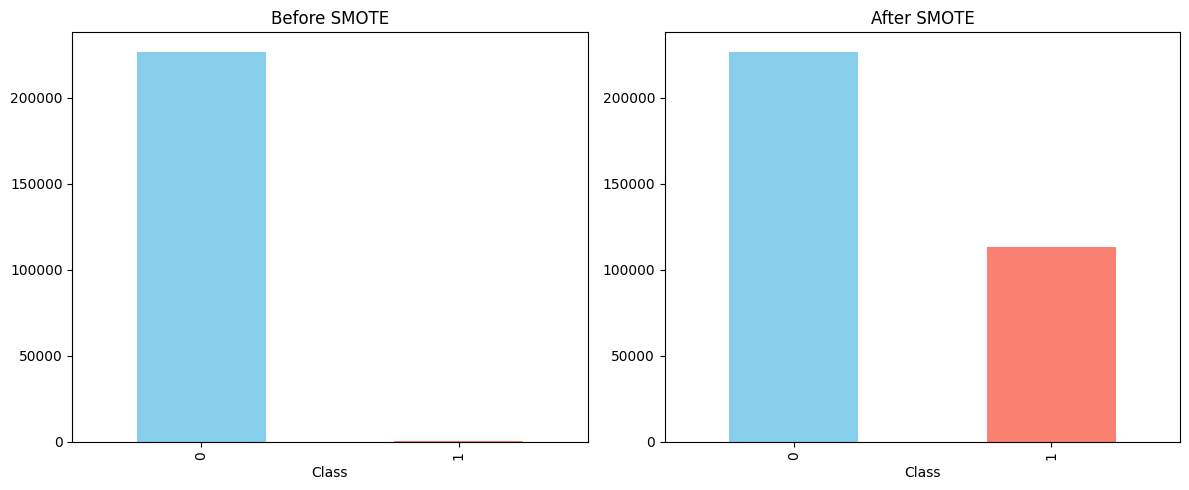

In [4]:
fraud_preprocessing=FraudDetectionPipeline('../data/processed/processedCreditData.csv', is_fraud=False)
X_train, y_train, X_test, y_test=fraud_preprocessing.run()

2026-06-13 13:20:05,637 - INFO - Training Baseline Logistic Regression...


The AUC ROC score:  0.96255299065655
The Average Precision Score:  0.7074146676361996
The F1 Score is  0.2515527950310559
THe True Negative: 56183 
 The False Postives: 468 
 The False Negatives: 14 
 The true Positives: 81
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00     56651
       Fraud       0.15      0.85      0.25        95

    accuracy                           0.99     56746
   macro avg       0.57      0.92      0.62     56746
weighted avg       1.00      0.99      0.99     56746



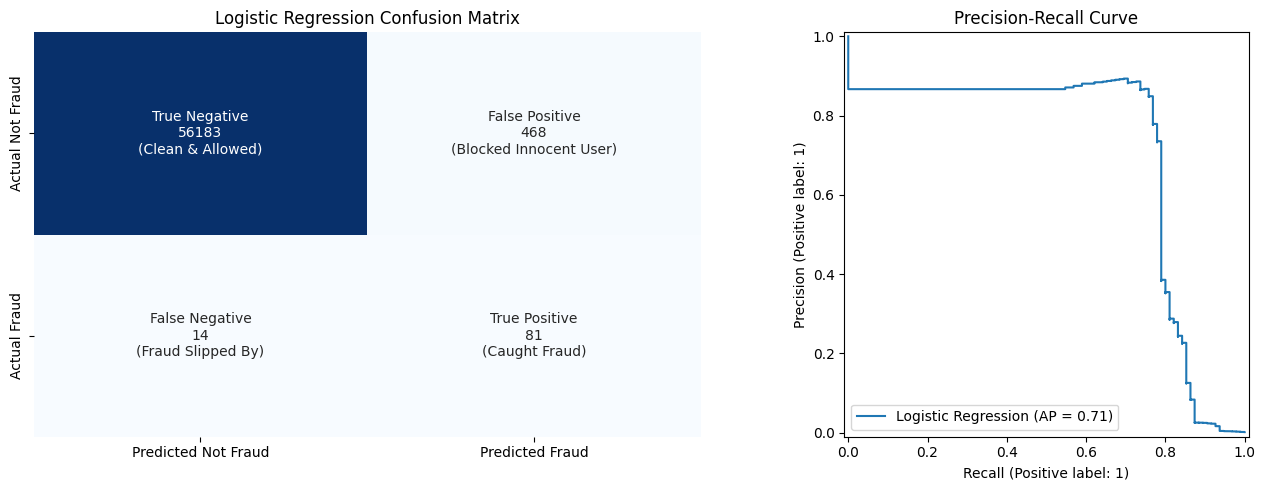

In [5]:
mt=ModelTrain(X_train, y_train, X_test, y_test)
lg = mt.train_log_reg(n_iter=10000)

2026-06-13 13:30:53,154 - INFO - Starting Hyperparameter Tuning for Random_Forest...
2026-06-13 14:55:03,261 - INFO - Best parameters for Random_Forest: {'max_depth': 15, 'n_estimators': 300}



PERFORMANCE METRICS FOR: RANDOM_FOREST
The Average Precision Score:   0.8072
The F1 Score:                  0.8021
Recall (Fraud Class):          0.7895
THe True Negative (True Non-Frauds): 56634 
 The False Postives (Non-Frauds being passed as Frauds): 17 
 The False Negatives (Frauds being passed as Non-Fruads): 20 
 The true Positives (True Fruads caught): 75
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.82      0.79      0.80        95

    accuracy                           1.00     56746
   macro avg       0.91      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------


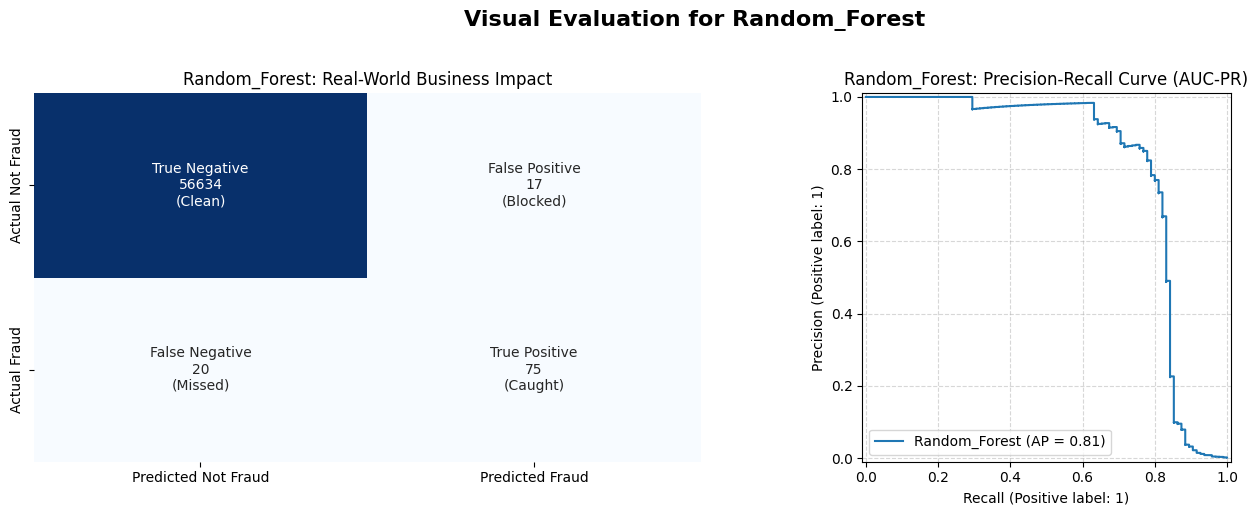

2026-06-13 14:55:10,461 - INFO - Starting Hyperparameter Tuning for XGBoost...
2026-06-13 15:00:39,134 - INFO - Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}



PERFORMANCE METRICS FOR: XGBOOST
The Average Precision Score:   0.8078
The F1 Score:                  0.8444
Recall (Fraud Class):          0.8000
THe True Negative (True Non-Frauds): 56642 
 The False Postives (Non-Frauds being passed as Frauds): 9 
 The False Negatives (Frauds being passed as Non-Fruads): 19 
 The true Positives (True Fruads caught): 76
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.89      0.80      0.84        95

    accuracy                           1.00     56746
   macro avg       0.95      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------


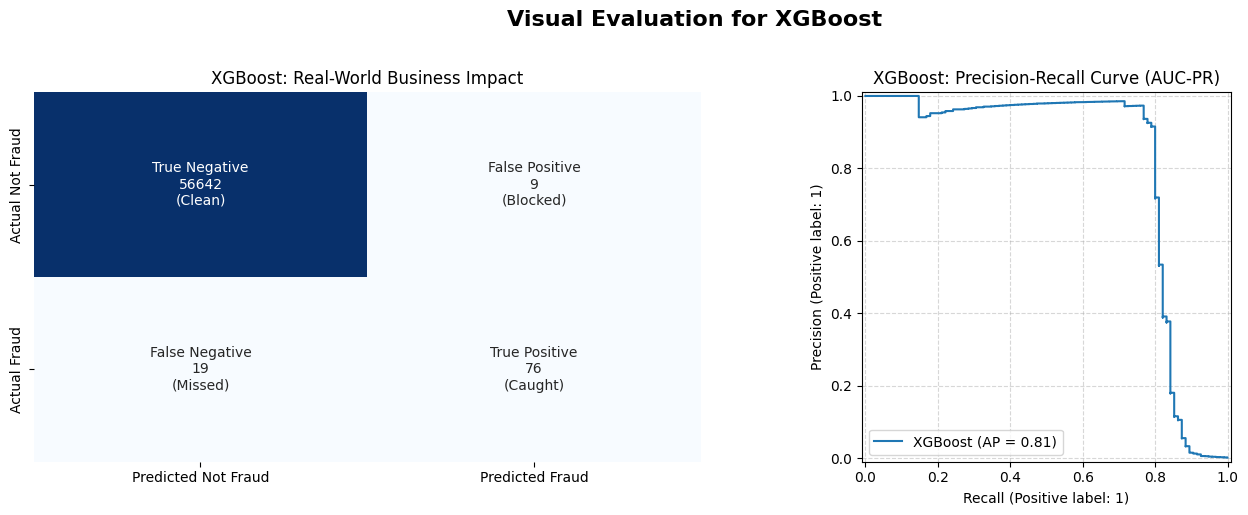

2026-06-13 15:00:42,747 - INFO - Starting Hyperparameter Tuning for LightGBM...
2026-06-13 15:06:41,588 - INFO - Best parameters for LightGBM: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}



PERFORMANCE METRICS FOR: LIGHTGBM
The Average Precision Score:   0.8164
The F1 Score:                  0.8306
Recall (Fraud Class):          0.8000
THe True Negative (True Non-Frauds): 56639 
 The False Postives (Non-Frauds being passed as Frauds): 12 
 The False Negatives (Frauds being passed as Non-Fruads): 19 
 The true Positives (True Fruads caught): 76
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.86      0.80      0.83        95

    accuracy                           1.00     56746
   macro avg       0.93      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------


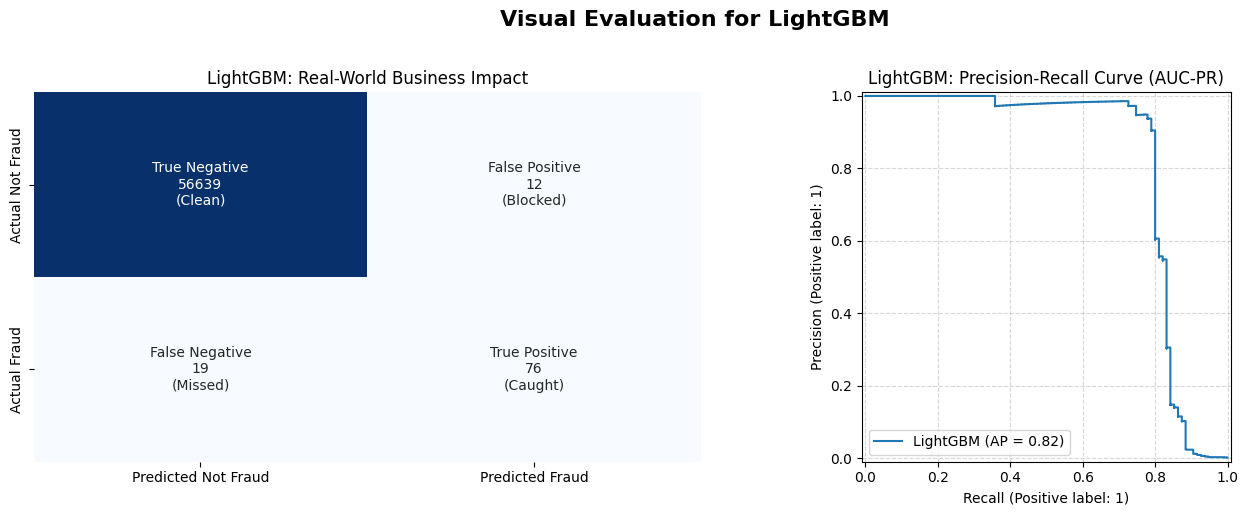

In [6]:
base_models=mt.train_and_evaluate_models()

In [7]:
mt.compare_all_models(best_models=base_models)

2026-06-13 15:06:49,678 - INFO - Running full CV comparison for Random_Forest...
2026-06-13 15:06:49,680 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for RandomForestClassifier...



MODEL COMPARISON: SIDE-BY-SIDE SUMMARY


2026-06-13 15:34:17,652 - INFO - Running full CV comparison for XGBoost...
2026-06-13 15:34:17,657 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for XGBClassifier...



CROSS-VALIDATION RESULTS for RandomForestClassifier
Average Precision        : 0.9999 ± 0.0000
Roc Auc                  : 1.0000 ± 0.0000
F1                       : 0.9994 ± 0.0001
Precision                : 0.9992 ± 0.0002
Recall                   : 0.9996 ± 0.0001

Per-fold scores:
Fold 1:
  Average Precision   : 1.0000
  Roc Auc             : 1.0000
  F1                  : 0.9995
  Precision           : 0.9995
  Recall              : 0.9995
Fold 2:
  Average Precision   : 1.0000
  Roc Auc             : 1.0000
  F1                  : 0.9996
  Precision           : 0.9994
  Recall              : 0.9999
Fold 3:
  Average Precision   : 1.0000
  Roc Auc             : 1.0000
  F1                  : 0.9994
  Precision           : 0.9992
  Recall              : 0.9996
Fold 4:
  Average Precision   : 0.9999
  Roc Auc             : 1.0000
  F1                  : 0.9993
  Precision           : 0.9990
  Recall              : 0.9996
Fold 5:
  Average Precision   : 0.9999
  Roc Auc             :

2026-06-13 15:35:48,505 - INFO - Running full CV comparison for LightGBM...
2026-06-13 15:35:48,508 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for LGBMClassifier...



CROSS-VALIDATION RESULTS for XGBClassifier
Average Precision        : 1.0000 ± 0.0000
Roc Auc                  : 1.0000 ± 0.0000
F1                       : 0.9997 ± 0.0001
Precision                : 0.9995 ± 0.0002
Recall                   : 1.0000 ± 0.0000

Per-fold scores:
Fold 1:
  Average Precision   : 1.0000
  Roc Auc             : 1.0000
  F1                  : 0.9999
  Precision           : 0.9998
  Recall              : 1.0000
Fold 2:
  Average Precision   : 1.0000
  Roc Auc             : 1.0000
  F1                  : 0.9998
  Precision           : 0.9996
  Recall              : 1.0000
Fold 3:
  Average Precision   : 1.0000
  Roc Auc             : 1.0000
  F1                  : 0.9996
  Precision           : 0.9993
  Recall              : 0.9999
Fold 4:
  Average Precision   : 1.0000
  Roc Auc             : 1.0000
  F1                  : 0.9997
  Precision           : 0.9993
  Recall              : 1.0000
Fold 5:
  Average Precision   : 1.0000
  Roc Auc             : 1.0000
 

{'Random_Forest': {'average_precision': np.float64(0.9999462650113372),
  'f1': np.float64(0.9994087800523663),
  'recall': np.float64(0.9996116543802895)},
 'XGBoost': {'average_precision': np.float64(0.9999846376317117),
  'f1': np.float64(0.9997220596972582),
  'recall': np.float64(0.9999735224029775)},
 'LightGBM': {'average_precision': np.float64(0.9999143043455982),
  'f1': np.float64(0.9997485219164813),
  'recall': np.float64(0.9999735224029775)}}

In [10]:
os.makedirs("../models/creditcard/", exist_ok=True)
for name, model in base_models.items(): joblib.dump(model, f"../models/creditcard/{name}_final_model.pkl")

## Credit Card Fraud Detection Model Comparison

### Executive Summary
This report compares four models trained on the **credit card fraud detection** dataset: **Logistic Regression**, **Random Forest**, **XGBoost**, and **LightGBM**. 

The dataset is highly imbalanced (~0.17% fraud cases), making metrics like **AUC-ROC**, **Average Precision (PR-AUC)**, **F1-score**, and the **precision-recall tradeoff** critical. 

**XGBoost** is the **recommended best model** due to its superior balance of high precision, strong F1-score, and minimal false positives while maintaining good fraud recall.

### Key Performance Metrics Comparison

| Model                | Avg Precision (PR-AUC) | F1-Score (Fraud) | Fraud Precision | Fraud Recall | True Positives | False Positives | False Negatives | Accuracy |
|----------------------|------------------------|------------------|-----------------|--------------|----------------|-----------------|-----------------|----------|
| **Logistic Regression** | 0.7074                | 0.2516          | 0.15           | **0.85**    | 81            | 468            | **14**         | 0.99    |
| **Random Forest**           | 0.8072                | 0.8021          | 0.82           | 0.7895      | 75            | 17             | 20             | 1.00    |
| **XGBoost**                  | 0.8078                | **0.8444**      | **0.89**       | 0.80        | **76**        | **9**          | 19             | 1.00    |
| **LightGBM**                  | **0.8164**            | 0.8306          | 0.86           | 0.80        | **76**        | 12             | 19             | 1.00    |

### Confusion Matrix Summary (Test Set, 56,746 samples)
- **Not Fraud**: 56,651 instances
- **Fraud**: 95 instances

### Detailed Model Analysis

#### 1. Logistic Regression
- **Strengths**: Highest fraud recall (0.85) → catches the most actual fraud cases (only 14 missed).
- **Weaknesses**: Extremely low precision (0.15) and F1-score (0.25). Produces **468 false positives**, nearly 5× more than the tree-based models.
- **Business Impact**: High operational cost from investigating hundreds of legitimate transactions. Poor customer experience due to frequent false fraud alerts.

#### 2. Random Forest
- Solid all-rounder with good precision (0.82) and recall (~0.79).
- Moderate false positives (17) and missed frauds (20).
- Lower F1 than boosted models.

#### 3. XGBoost (Recommended)
- **Best overall performer**.
- Highest F1-score (**0.8444**) for the fraud class.
- Highest precision (**0.89**) among all models → very few false alarms (only **9**).
- Strong recall (0.80) and catches **76** out of 95 frauds.
- Excellent PR-AUC (0.8078).

#### 4. LightGBM
- Highest Average Precision (**0.8164**).
- Very close to XGBoost in performance.
- Slightly higher false positives (12) than XGBoost.

### Precision-Recall Tradeoff Analysis

In fraud detection, there is an inherent **precision-recall tradeoff**:

- **High Recall** (catch most frauds) → More False Positives → Higher investigation/review costs + customer friction.
- **High Precision** (fewer false alarms) → Risk of missing some frauds → Direct financial losses.

**Business Cost Considerations**:
- **False Negative (Missed Fraud)**: Direct monetary loss (average fraud amount varies, but often high).
- **False Positive**: Customer inconvenience, potential card blocking, support tickets, manual review labor costs.
- **Regulatory/Reputational Risk**: Too many false positives erode customer trust; too many missed frauds increase financial and compliance risk.

**Logistic Regression** prioritizes recall at the expense of massive precision degradation → not viable in production due to alert fatigue.

**Tree-based models** (RF, XGBoost, LightGBM) achieve a much better balance. **XGBoost** offers the **sweet spot**: it maintains strong recall (80%) while delivering the **highest precision** and **lowest false positives**, minimizing operational burden while controlling fraud losses effectively.

### Business Justifications & Recommendations

#### Why XGBoost is the Best Choice:
1. **Lowest Operational Cost**: Only 9 false positives, drastically reduces manual review workload compared to Logistic Regression (468) or even LightGBM (12).
2. **High Fraud Capture**: Catches 76/95 fraud cases (80% recall), strong protection against financial loss.
3. **Best F1-Score**: Optimal harmonic mean of precision and recall for the minority (fraud) class.
4. **Scalability & Speed**: XGBoost is fast to train and predict, suitable for real-time transaction scoring.
5. **Robustness**: Performs well on imbalanced data without excessive tuning.


